# 03 — E-GEO Pretrained Neural Retrieval/Reranker Analysis across All LLM Labels

This notebook assumes notebooks **01** and **02** have already been run.

It uses the existing E-GEO ranking traces from all available models:

- GPT-5
- GPT-4.1
- Gemini
- Claude
- DeepSeek
- Llama

Goal:

> Test whether off-the-shelf pretrained neural retrieval and reranking models can recover existing LLM shopping-ranking visibility across model-specific labels.

This notebook does **not** fine-tune any model and does **not** call any LLM API.  
It downloads pretrained models from Hugging Face the first time you run it.

Expected Google Drive structure:

```text
MyDrive/
└── Finance Research/
    └── E-GEO-ML/
        ├── code/
        │   └── 03_egeo_all_models_pretrained_neural_reranker_colab.ipynb
        ├── raw_data/
        ├── data/
        │   ├── egeo_train_val_visibility_long_all_models.csv
        │   ├── egeo_gpt5_internal_valid_split.csv
        │   ├── egeo_cross_model_robustness_metrics.csv
        │   └── ...
        ├── figures/
        ├── results/
        └── models/
```

The notebook can be run in Google Colab or JupyterLab.


## 1. Install packages

Run this cell once in Colab/JupyterLab.

The pretrained models will be downloaded automatically when first used.


In [1]:
# Colab / JupyterLab install cell
# If this is already installed, this cell will be quick.

%pip install -U sentence-transformers tqdm accelerate


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.7/58.7 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 8.6 MB/s eta 0:00:00
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.67.3
    Uninstalling tqdm-4.67.3:
      Successfully uninstalled tqdm-4.67.3


## 2. Mount Google Drive and configure project paths

For Colab, this mounts Google Drive and points to:

```text
/content/drive/MyDrive/Finance Research/E-GEO-ML
```

If you are running locally or in JupyterLab, the path detection will also work if the notebook is inside `E-GEO-ML/code`.


In [2]:
from pathlib import Path
import os
import sys
import warnings
import math
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Mount Google Drive if running in Colab
# ------------------------------------------------------------
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

# ------------------------------------------------------------
# Project root configuration
# ------------------------------------------------------------
# Update this if your Drive folder name changes.
COLAB_PROJECT_ROOT = Path("/content/drive/MyDrive/Finance Research/E-GEO-ML")

CWD = Path.cwd().resolve()

if IN_COLAB and COLAB_PROJECT_ROOT.exists():
    PROJECT_ROOT = COLAB_PROJECT_ROOT
elif (CWD / "data").exists() and (CWD / "raw_data").exists():
    PROJECT_ROOT = CWD
elif (CWD.parent / "data").exists() and (CWD.parent / "raw_data").exists():
    PROJECT_ROOT = CWD.parent
else:
    PROJECT_ROOT = CWD.parent if CWD.name.lower() == "code" else CWD

CODE_DIR = PROJECT_ROOT / "code"
RAW_DATA_DIR = PROJECT_ROOT / "raw_data"
DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"
MODELS_DIR = PROJECT_ROOT / "models"
HF_CACHE_DIR = MODELS_DIR / "hf_cache"

for d in [DATA_DIR, FIGURES_DIR, RESULTS_DIR, MODELS_DIR, HF_CACHE_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# Put Hugging Face cache inside project models/ so downloads are reusable.
os.environ["HF_HOME"] = str(HF_CACHE_DIR)
os.environ["TRANSFORMERS_CACHE"] = str(HF_CACHE_DIR / "transformers")
os.environ["SENTENCE_TRANSFORMERS_HOME"] = str(HF_CACHE_DIR / "sentence_transformers")

print("IN_COLAB:", IN_COLAB)
print("Current working directory:", CWD)
print("Project root:", PROJECT_ROOT)
print("Data directory:", DATA_DIR)
print("Figures directory:", FIGURES_DIR)
print("Models directory:", MODELS_DIR)
print("HF cache:", HF_CACHE_DIR)

assert DATA_DIR.exists(), f"data folder not found: {DATA_DIR}"


Mounted at /content/drive
IN_COLAB: True
Current working directory: /content
Project root: /content/drive/MyDrive/Finance Research/E-GEO-ML
Data directory: /content/drive/MyDrive/Finance Research/E-GEO-ML/data
Figures directory: /content/drive/MyDrive/Finance Research/E-GEO-ML/figures
Models directory: /content/drive/MyDrive/Finance Research/E-GEO-ML/models
HF cache: /content/drive/MyDrive/Finance Research/E-GEO-ML/models/hf_cache


## 3. Runtime configuration

This notebook is heavier than the previous ones because it runs pretrained neural models.

Recommended setting:

- Keep all embedding models enabled.
- Keep cross-encoder MiniLM enabled.
- BGE reranker is stronger but slower, so it is optional.
- If runtime is too long, set `MAX_UNIQUE_ROWS_FOR_DEBUG = 2000` first.


In [3]:
# ------------------------------------------------------------
# Runtime controls
# ------------------------------------------------------------

# For a full run, keep this as None.
# For a quick test, set to 1000 or 2000.
MAX_UNIQUE_ROWS_FOR_DEBUG = None

# Pretrained embedding models.
RUN_EMBEDDING_MODELS = True
EMBEDDING_MODELS = [
    {
        "short_name": "embed_minilm_l6",
        "model_name": "sentence-transformers/all-MiniLM-L6-v2",
        "prompt_style": "default",
        "batch_size": 128,
    },
    {
        "short_name": "embed_multiqa_minilm",
        "model_name": "sentence-transformers/multi-qa-MiniLM-L6-cos-v1",
        "prompt_style": "default",
        "batch_size": 128,
    },
    {
        "short_name": "embed_e5_base",
        "model_name": "intfloat/e5-base-v2",
        "prompt_style": "e5",
        "batch_size": 64,
    },
]

# Pretrained cross-encoder / reranker models.
RUN_CROSS_ENCODERS = True
CROSS_ENCODER_MODELS = [
    {
        "short_name": "rerank_msmarco_minilm_l6",
        "model_name": "cross-encoder/ms-marco-MiniLM-L6-v2",
        "batch_size": 64,
    },
    {
        "short_name": "rerank_msmarco_minilm_l12",
        "model_name": "cross-encoder/ms-marco-MiniLM-L12-v2",
        "batch_size": 32,
    },
]

# Optional stronger reranker. It can be slower.
RUN_BGE_RERANKER = True
BGE_RERANKER = {
    "short_name": "rerank_bge_base",
    "model_name": "BAAI/bge-reranker-base",
    "batch_size": 16,
}

# If a score column already exists in the saved score file, skip recomputing it.
FORCE_RECOMPUTE_SCORES = False

print("MAX_UNIQUE_ROWS_FOR_DEBUG:", MAX_UNIQUE_ROWS_FOR_DEBUG)
print("RUN_EMBEDDING_MODELS:", RUN_EMBEDDING_MODELS)
print("RUN_CROSS_ENCODERS:", RUN_CROSS_ENCODERS)
print("RUN_BGE_RERANKER:", RUN_BGE_RERANKER)


MAX_UNIQUE_ROWS_FOR_DEBUG: None
RUN_EMBEDDING_MODELS: True
RUN_CROSS_ENCODERS: True
RUN_BGE_RERANKER: True


## 4. Load all-model E-GEO outputs from notebook 01

The key file is:

```text
data/egeo_train_val_visibility_long_all_models.csv
```

It contains the same query-product rows repeated for each LLM label model, with columns such as:

```text
model, rank, top3, visibility_score, questionable
```


In [4]:
def read_csv_required(path, **kwargs):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Required file missing: {path}")
    print(f"Loaded: {path.name}")
    return pd.read_csv(path, **kwargs)


def read_csv_optional(path, **kwargs):
    path = Path(path)
    if path.exists():
        print(f"Loaded: {path.name}")
        return pd.read_csv(path, **kwargs)
    print(f"Missing optional file: {path.name}")
    return None


visibility_long = read_csv_required(DATA_DIR / "egeo_train_val_visibility_long_all_models.csv")
gpt5_valid_split = read_csv_optional(DATA_DIR / "egeo_gpt5_internal_valid_split.csv")
prior_cross_model_metrics = read_csv_optional(DATA_DIR / "egeo_cross_model_robustness_metrics.csv")
prior_gpt5_row_metrics = read_csv_optional(DATA_DIR / "egeo_gpt5_classification_metrics_valid.csv", index_col=0)
prior_gpt5_query_metrics = read_csv_optional(DATA_DIR / "egeo_gpt5_query_level_metrics_valid.csv", index_col=0)

visibility_long["query_id"] = visibility_long["query_id"].astype(str)

print("\nAll-model visibility dataset:", visibility_long.shape)
print("Available label models:", sorted(visibility_long["model"].unique()))
print("Rows by label model:")
display(visibility_long.groupby("model").size().rename("n_rows").to_frame())
display(visibility_long.head())


Loaded: egeo_train_val_visibility_long_all_models.csv
Loaded: egeo_gpt5_internal_valid_split.csv
Missing optional file: egeo_cross_model_robustness_metrics.csv
Loaded: egeo_gpt5_classification_metrics_valid.csv
Loaded: egeo_gpt5_query_level_metrics_valid.csv

All-model visibility dataset: (118900, 49)
Available label models: ['claude', 'deepseek', 'gemini', 'gpt41', 'gpt5', 'llama']
Rows by label model:


,n_rows
model,
claude,20000
deepseek,19383
gemini,20000
gpt41,19999
gpt5,19600
llama,19918


,split,query_id,custom_id,query,product_num,product_id,title,store,main_category,features,...,log_rating_number,numeric_count_product_text,numeric_count_title,numeric_count_features,numeric_count_details,evidence_keyword_count,query_title_overlap,query_features_overlap,query_product_overlap,query_product_pair_text
0,train_val,10,50,CB Radio: What is considered the AK47 of autom...,1,B00000K39B,Midland 77-092 40-Channel CB Radio,Midland,Cell Phones & Accessories,40 CB channels Solid state switching Coiled-co...,...,1.791759,33,3,1,10,15,0.2,0.1,0.6,QUERY: CB Radio: What is considered the AK47 o...
1,train_val,10,50,CB Radio: What is considered the AK47 of autom...,1,B00000K39B,Midland 77-092 40-Channel CB Radio,Midland,Cell Phones & Accessories,40 CB channels Solid state switching Coiled-co...,...,1.791759,33,3,1,10,15,0.2,0.1,0.6,QUERY: CB Radio: What is considered the AK47 o...
2,train_val,10,50,CB Radio: What is considered the AK47 of autom...,1,B00000K39B,Midland 77-092 40-Channel CB Radio,Midland,Cell Phones & Accessories,40 CB channels Solid state switching Coiled-co...,...,1.791759,33,3,1,10,15,0.2,0.1,0.6,QUERY: CB Radio: What is considered the AK47 o...
3,train_val,10,50,CB Radio: What is considered the AK47 of autom...,1,B00000K39B,Midland 77-092 40-Channel CB Radio,Midland,Cell Phones & Accessories,40 CB channels Solid state switching Coiled-co...,...,1.791759,33,3,1,10,15,0.2,0.1,0.6,QUERY: CB Radio: What is considered the AK47 o...
4,train_val,10,50,CB Radio: What is considered the AK47 of autom...,1,B00000K39B,Midland 77-092 40-Channel CB Radio,Midland,Cell Phones & Accessories,40 CB channels Solid state switching Coiled-co...,...,1.791759,33,3,1,10,15,0.2,0.1,0.6,QUERY: CB Radio: What is considered the AK47 o...


## 5. Use the same validation queries as notebook 01

To make the comparison fair, this notebook uses the same validation query IDs created in notebook 01.

If the GPT-5 validation split file is missing, it falls back to all rows.


In [5]:
if gpt5_valid_split is not None:
    gpt5_valid_split["query_id"] = gpt5_valid_split["query_id"].astype(str)
    valid_query_ids = set(gpt5_valid_split["query_id"].unique())
    eval_long = visibility_long[visibility_long["query_id"].isin(valid_query_ids)].copy()
    print("Using notebook 01 GPT-5 validation query split.")
else:
    eval_long = visibility_long.copy()
    print("No validation split found. Using all train_val rows for evaluation.")

print("Evaluation long rows:", eval_long.shape)
print("Evaluation queries:", eval_long["query_id"].nunique())
print("Rows by label model in evaluation set:")
display(eval_long.groupby("model").size().rename("n_rows").to_frame())


Using notebook 01 GPT-5 validation query split.
Evaluation long rows: (23471, 49)
Evaluation queries: 392
Rows by label model in evaluation set:


,n_rows
model,
claude,3920
deepseek,3878
gemini,3920
gpt41,3920
gpt5,3920
llama,3913


## 6. Build unique query-product table

Pretrained neural scores do not depend on which LLM label model we evaluate against.

So we compute them once per unique query-product pair, then merge the scores back onto each model-specific label set.


In [6]:
def clean_spaces(text):
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


def truncate_words(text, max_words=280):
    words = clean_spaces(text).split()
    if len(words) <= max_words:
        return " ".join(words)
    return " ".join(words[:max_words])


def make_compact_product_text(row, max_words=280):
    parts = []

    title = clean_spaces(row.get("title", ""))
    store = clean_spaces(row.get("store", ""))
    category = clean_spaces(row.get("main_category", ""))
    features = clean_spaces(row.get("features", ""))
    description = clean_spaces(row.get("description", ""))
    details = clean_spaces(row.get("details", ""))

    if title:
        parts.append(f"Title: {title}")
    if store:
        parts.append(f"Brand or store: {store}")
    if category:
        parts.append(f"Category: {category}")
    if features:
        parts.append(f"Features: {features}")
    if description:
        parts.append(f"Description: {description}")
    if details:
        parts.append(f"Details: {details}")

    return truncate_words(" ".join(parts), max_words=max_words)


base_cols = [
    "query_id", "product_num", "product_id", "query", "title", "store",
    "main_category", "features", "description", "details", "product_text"
]
base_cols = [c for c in base_cols if c in eval_long.columns]

unique_pairs = (
    eval_long[base_cols]
    .drop_duplicates(subset=["query_id", "product_num"])
    .sort_values(["query_id", "product_num"])
    .reset_index(drop=True)
)

unique_pairs["query_clean"] = unique_pairs["query"].fillna("").map(clean_spaces)
unique_pairs["product_text_compact"] = unique_pairs.apply(make_compact_product_text, axis=1)
unique_pairs["query_product_pair_compact"] = (
    "Query: " + unique_pairs["query_clean"] +
    " Product: " + unique_pairs["product_text_compact"]
)

if MAX_UNIQUE_ROWS_FOR_DEBUG is not None:
    unique_pairs = unique_pairs.head(MAX_UNIQUE_ROWS_FOR_DEBUG).copy()
    allowed = set(zip(unique_pairs["query_id"], unique_pairs["product_num"]))
    eval_long = eval_long[
        list(zip(eval_long["query_id"], eval_long["product_num"])).isin(allowed)
    ].copy()

print("Unique query-product rows to score:", unique_pairs.shape)
display(unique_pairs.head())

print("\nExample compact product text:")
print(unique_pairs.loc[0, "product_text_compact"][:1200])


Unique query-product rows to score: (3920, 14)


,query_id,product_num,product_id,query,title,store,main_category,features,description,details,product_text,query_clean,product_text_compact,query_product_pair_compact
0,10123,1,B008S1KLUW,Finding good deals on office chairs similar to...,Steelcase Leap V1 High Back Office Chair -Blac...,Steelcase,Amazon Home,Our #1 selling ergonomic office chair Patented...,NaN,"Color Black Product Dimensions 21.75""D x 27""W ...",Steelcase Leap V1 High Back Office Chair -Blac...,Finding good deals on office chairs similar to...,Title: Steelcase Leap V1 High Back Office Chai...,Query: Finding good deals on office chairs sim...
1,10123,2,B00I7QWHUA,Finding good deals on office chairs similar to...,"Steelcase Leap Office Desk Chair, Soapstone Le...",Steelcase,Amazon Home,Our Number 1 Selling Chair Live Back technolog...,The Steelcase Leap chair is the first chair th...,Color Grey Brand Steelcase Product Dimensions ...,"Steelcase Leap Office Desk Chair, Soapstone Le...",Finding good deals on office chairs similar to...,"Title: Steelcase Leap Office Desk Chair, Soaps...",Query: Finding good deals on office chairs sim...
2,10123,3,B0B5QG13S7,Finding good deals on office chairs similar to...,Office Chair - Ergonomic Home Office Chairs wi...,JHK,Amazon Home,【MATERIALS】- The executive office chair is mad...,Nice home office chair,Brand JHK Color Dark Black Material Metal Prod...,Office Chair - Ergonomic Home Office Chairs wi...,Finding good deals on office chairs similar to...,Title: Office Chair - Ergonomic Home Office Ch...,Query: Finding good deals on office chairs sim...
3,10123,4,B07TT7ZNFD,Finding good deals on office chairs similar to...,Steelcase Chairs - High Back Criterion Chair R...,cubicles.com - Steelcase Chairs,Amazon Home,FEATURES & ERGONOMICS: Adjustable ergonomic ch...,"The Steelcase Criterion chair's soft curves, t...",Brand cubicles.com - Steelcase Chairs Color Bl...,Steelcase Chairs - High Back Criterion Chair R...,Finding good deals on office chairs similar to...,Title: Steelcase Chairs - High Back Criterion ...,Query: Finding good deals on office chairs sim...
4,10123,5,B00I8DHUMC,Finding good deals on office chairs similar to...,"Steelcase Office Chair, Black",Steelcase,Amazon Home,"Leap plus offers the same benefits, aesthetic ...",The Steelcase Leap plus chair offers the same ...,Brand Steelcase Color Black Material Textile P...,"Steelcase Office Chair, Black Steelcase Amazon...",Finding good deals on office chairs similar to...,"Title: Steelcase Office Chair, Black Brand or ...",Query: Finding good deals on office chairs sim...



Example compact product text:
Title: Steelcase Leap V1 High Back Office Chair -Black Fabric Brand or store: Steelcase Category: Amazon Home Features: Our #1 selling ergonomic office chair Patented Live Back technology Amazing ergonomic comfort - Natural Glide System Pneumatic seat height Adjustable arms & Back Stop Black plastic outer back, frame, and base Details: Color Black Product Dimensions 21.75"D x 27"W x 38.5"H Item Weight 48 Pounds Frame Material Alloy Steel Special Feature Ergonomic


## 7. Score file with resume support

If the notebook stops midway, rerun it.  
Previously computed score columns will be loaded from:

```text
data/egeo_pretrained_neural_scores_unique_query_product.csv
```


In [7]:
SCORES_PATH = DATA_DIR / "egeo_pretrained_neural_scores_unique_query_product.csv"

key_cols = ["query_id", "product_num"]
text_cols = [
    "product_id", "query", "title", "query_clean",
    "product_text_compact", "query_product_pair_compact"
]
text_cols = [c for c in text_cols if c in unique_pairs.columns]

if SCORES_PATH.exists():
    existing_scores = pd.read_csv(SCORES_PATH)
    existing_scores["query_id"] = existing_scores["query_id"].astype(str)
    print("Loaded existing score file:", SCORES_PATH.name, existing_scores.shape)

    score_cols_existing = [
        c for c in existing_scores.columns
        if c not in set(key_cols + text_cols)
    ]

    scores_df = unique_pairs[key_cols + text_cols].merge(
        existing_scores[key_cols + score_cols_existing],
        on=key_cols,
        how="left"
    )
else:
    scores_df = unique_pairs[key_cols + text_cols].copy()
    print("No existing score file found. Starting fresh.")

display(scores_df.head())
print("Existing score columns:", [c for c in scores_df.columns if c not in key_cols + text_cols])


No existing score file found. Starting fresh.


,query_id,product_num,product_id,query,title,query_clean,product_text_compact,query_product_pair_compact
0,10123,1,B008S1KLUW,Finding good deals on office chairs similar to...,Steelcase Leap V1 High Back Office Chair -Blac...,Finding good deals on office chairs similar to...,Title: Steelcase Leap V1 High Back Office Chai...,Query: Finding good deals on office chairs sim...
1,10123,2,B00I7QWHUA,Finding good deals on office chairs similar to...,"Steelcase Leap Office Desk Chair, Soapstone Le...",Finding good deals on office chairs similar to...,"Title: Steelcase Leap Office Desk Chair, Soaps...",Query: Finding good deals on office chairs sim...
2,10123,3,B0B5QG13S7,Finding good deals on office chairs similar to...,Office Chair - Ergonomic Home Office Chairs wi...,Finding good deals on office chairs similar to...,Title: Office Chair - Ergonomic Home Office Ch...,Query: Finding good deals on office chairs sim...
3,10123,4,B07TT7ZNFD,Finding good deals on office chairs similar to...,Steelcase Chairs - High Back Criterion Chair R...,Finding good deals on office chairs similar to...,Title: Steelcase Chairs - High Back Criterion ...,Query: Finding good deals on office chairs sim...
4,10123,5,B00I8DHUMC,Finding good deals on office chairs similar to...,"Steelcase Office Chair, Black",Finding good deals on office chairs similar to...,"Title: Steelcase Office Chair, Black Brand or ...",Query: Finding good deals on office chairs sim...


Existing score columns: []


## 8. Lexical baseline: TF-IDF query-product cosine

This is not neural, but it is important as a lexical retrieval baseline.


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

score_col = "score_tfidf_compact_cosine"

if FORCE_RECOMPUTE_SCORES or score_col not in scores_df.columns or scores_df[score_col].isna().all():
    print("Computing TF-IDF cosine baseline...")

    corpus = pd.concat([
        scores_df["query_clean"].fillna(""),
        scores_df["product_text_compact"].fillna("")
    ], ignore_index=True)

    tfidf = TfidfVectorizer(
        max_features=50000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        lowercase=True,
        strip_accents="unicode"
    )
    tfidf.fit(corpus)

    q_mat = tfidf.transform(scores_df["query_clean"].fillna(""))
    p_mat = tfidf.transform(scores_df["product_text_compact"].fillna(""))
    scores_df[score_col] = np.asarray(q_mat.multiply(p_mat).sum(axis=1)).ravel()

    scores_df.to_csv(SCORES_PATH, index=False)
    print("Saved:", SCORES_PATH)
else:
    print("Skipping TF-IDF; score already exists.")

display(scores_df[[*key_cols, score_col]].head())


Computing TF-IDF cosine baseline...
Saved: /content/drive/MyDrive/Finance Research/E-GEO-ML/data/egeo_pretrained_neural_scores_unique_query_product.csv


,query_id,product_num,score_tfidf_compact_cosine
0,10123,1,0.110080
1,10123,2,0.160468
2,10123,3,0.077607
3,10123,4,0.156792
4,10123,5,0.139919


## 9. Pretrained embedding models

Each embedding model encodes query and product text separately.

Then we compute:

```text
cosine(query_embedding, product_embedding)
```

This evaluates semantic query-product matching without fine-tuning.


In [9]:
if RUN_EMBEDDING_MODELS:
    try:
        from sentence_transformers import SentenceTransformer

        for cfg in EMBEDDING_MODELS:
            short_name = cfg["short_name"]
            model_name = cfg["model_name"]
            prompt_style = cfg.get("prompt_style", "default")
            batch_size = cfg.get("batch_size", 64)
            score_col = f"score_{short_name}_cosine"

            if (not FORCE_RECOMPUTE_SCORES) and score_col in scores_df.columns and not scores_df[score_col].isna().all():
                print(f"Skipping {short_name}; score already exists.")
                continue

            print("\n" + "=" * 80)
            print("Loading embedding model:", model_name)
            start = time.time()

            model = SentenceTransformer(model_name, cache_folder=str(HF_CACHE_DIR / "sentence_transformers"))

            if prompt_style == "e5":
                query_texts = ("query: " + scores_df["query_clean"].fillna("")).tolist()
                product_texts = ("passage: " + scores_df["product_text_compact"].fillna("")).tolist()
            else:
                query_texts = scores_df["query_clean"].fillna("").tolist()
                product_texts = scores_df["product_text_compact"].fillna("").tolist()

            print(f"Encoding queries with {short_name}...")
            q_emb = model.encode(
                query_texts,
                batch_size=batch_size,
                show_progress_bar=True,
                convert_to_numpy=True,
                normalize_embeddings=True,
            )

            print(f"Encoding products with {short_name}...")
            p_emb = model.encode(
                product_texts,
                batch_size=batch_size,
                show_progress_bar=True,
                convert_to_numpy=True,
                normalize_embeddings=True,
            )

            scores_df[score_col] = np.sum(q_emb * p_emb, axis=1)

            scores_df.to_csv(SCORES_PATH, index=False)
            print(f"Saved {score_col} to {SCORES_PATH.name}")
            print(f"Finished {short_name} in {(time.time() - start) / 60:.2f} minutes.")

    except Exception as e:
        print("Embedding model section failed.")
        print("Reason:", repr(e))
else:
    print("Embedding models skipped.")



Loading embedding model: sentence-transformers/all-MiniLM-L6-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Encoding queries with embed_e5_base...


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Encoding products with embed_e5_base...


Batches:   0%|          | 0/62 [00:00<?, ?it/s]

Saved score_embed_e5_base_cosine to egeo_pretrained_neural_scores_unique_query_product.csv
Finished embed_e5_base in 3.60 minutes.


## 10. Pretrained cross-encoder rerankers

Cross-encoders score the query and product text **together**:

```text
(query, product text) → relevance score
```

This is usually the strongest off-the-shelf pretrained baseline for ranking-style tasks.


In [10]:
if RUN_CROSS_ENCODERS:
    try:
        from sentence_transformers import CrossEncoder

        all_cross_configs = list(CROSS_ENCODER_MODELS)
        if RUN_BGE_RERANKER:
            all_cross_configs.append(BGE_RERANKER)

        pairs = list(zip(
            scores_df["query_clean"].fillna("").tolist(),
            scores_df["product_text_compact"].fillna("").tolist()
        ))

        for cfg in all_cross_configs:
            short_name = cfg["short_name"]
            model_name = cfg["model_name"]
            batch_size = cfg.get("batch_size", 32)
            score_col = f"score_{short_name}"

            if (not FORCE_RECOMPUTE_SCORES) and score_col in scores_df.columns and not scores_df[score_col].isna().all():
                print(f"Skipping {short_name}; score already exists.")
                continue

            print("\n" + "=" * 80)
            print("Loading cross-encoder/reranker:", model_name)
            start = time.time()

            try:
                ce = CrossEncoder(model_name, max_length=512)

                print(f"Scoring pairs with {short_name}...")
                pred_scores = ce.predict(
                    pairs,
                    batch_size=batch_size,
                    show_progress_bar=True,
                )

                scores_df[score_col] = np.asarray(pred_scores, dtype=float)
                scores_df.to_csv(SCORES_PATH, index=False)

                print(f"Saved {score_col} to {SCORES_PATH.name}")
                print(f"Finished {short_name} in {(time.time() - start) / 60:.2f} minutes.")

            except Exception as inner_e:
                print(f"Failed to run {short_name}. Skipping this model.")
                print("Reason:", repr(inner_e))

    except Exception as e:
        print("Cross-encoder section failed.")
        print("Reason:", repr(e))
else:
    print("Cross-encoders skipped.")



Loading cross-encoder/reranker: cross-encoder/ms-marco-MiniLM-L6-v2


config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/279 [00:00<?, ?B/s]

Scoring pairs with rerank_bge_base...


Batches:   0%|          | 0/245 [00:00<?, ?it/s]

Saved score_rerank_bge_base to egeo_pretrained_neural_scores_unique_query_product.csv
Finished rerank_bge_base in 5.81 minutes.


## 11. Hybrid score

This creates a simple non-trained ensemble:

1. Normalize each score within each query.
2. Average all available pretrained/lexical scores.

This is useful because different pretrained models capture slightly different relevance signals.


In [11]:
def minmax_by_query(df, score_col, new_col):
    out = df.copy()

    def scale_group(g):
        vals = g[score_col].astype(float).to_numpy()
        if np.all(np.isnan(vals)):
            g[new_col] = np.nan
            return g
        mn = np.nanmin(vals)
        mx = np.nanmax(vals)
        if mx - mn < 1e-12:
            g[new_col] = 0.5
        else:
            g[new_col] = (vals - mn) / (mx - mn)
        return g

    return out.groupby("query_id", group_keys=False).apply(scale_group)


raw_score_cols = [c for c in scores_df.columns if c.startswith("score_") and not c.endswith("_qnorm")]
print("Raw score columns:", raw_score_cols)

norm_cols = []
for col in raw_score_cols:
    norm_col = col + "_qnorm"
    scores_df = minmax_by_query(scores_df, col, norm_col)
    norm_cols.append(norm_col)

if len(norm_cols) >= 2:
    scores_df["score_hybrid_all_available"] = scores_df[norm_cols].mean(axis=1)
    print("Created score_hybrid_all_available from:", norm_cols)
else:
    print("Not enough score columns for hybrid.")

scores_df.to_csv(SCORES_PATH, index=False)
display(scores_df.head())


Raw score columns: ['score_tfidf_compact_cosine', 'score_embed_minilm_l6_cosine', 'score_embed_multiqa_minilm_cosine', 'score_embed_e5_base_cosine', 'score_rerank_msmarco_minilm_l6', 'score_rerank_msmarco_minilm_l12', 'score_rerank_bge_base']
Created score_hybrid_all_available from: ['score_tfidf_compact_cosine_qnorm', 'score_embed_minilm_l6_cosine_qnorm', 'score_embed_multiqa_minilm_cosine_qnorm', 'score_embed_e5_base_cosine_qnorm', 'score_rerank_msmarco_minilm_l6_qnorm', 'score_rerank_msmarco_minilm_l12_qnorm', 'score_rerank_bge_base_qnorm']


,query_id,product_num,product_id,query,title,query_clean,product_text_compact,query_product_pair_compact,score_tfidf_compact_cosine,score_embed_minilm_l6_cosine,...,score_rerank_msmarco_minilm_l12,score_rerank_bge_base,score_tfidf_compact_cosine_qnorm,score_embed_minilm_l6_cosine_qnorm,score_embed_multiqa_minilm_cosine_qnorm,score_embed_e5_base_cosine_qnorm,score_rerank_msmarco_minilm_l6_qnorm,score_rerank_msmarco_minilm_l12_qnorm,score_rerank_bge_base_qnorm,score_hybrid_all_available
0,10123,1,B008S1KLUW,Finding good deals on office chairs similar to...,Steelcase Leap V1 High Back Office Chair -Blac...,Finding good deals on office chairs similar to...,Title: Steelcase Leap V1 High Back Office Chai...,Query: Finding good deals on office chairs sim...,0.110080,0.680374,...,2.472633,0.308278,0.614761,0.847969,0.688858,0.927363,0.856977,0.828502,0.352078,0.730930
1,10123,2,B00I7QWHUA,Finding good deals on office chairs similar to...,"Steelcase Leap Office Desk Chair, Soapstone Le...",Finding good deals on office chairs similar to...,"Title: Steelcase Leap Office Desk Chair, Soaps...",Query: Finding good deals on office chairs sim...,0.160468,0.693191,...,3.946967,0.873788,1.000000,1.000000,1.000000,1.000000,0.988158,0.958616,1.000000,0.992396
2,10123,3,B0B5QG13S7,Finding good deals on office chairs similar to...,Office Chair - Ergonomic Home Office Chairs wi...,Finding good deals on office chairs similar to...,Title: Office Chair - Ergonomic Home Office Ch...,Query: Finding good deals on office chairs sim...,0.077607,0.658110,...,-3.510720,0.003454,0.366493,0.583882,0.424641,0.407446,0.316394,0.300454,0.002831,0.343163
3,10123,4,B07TT7ZNFD,Finding good deals on office chairs similar to...,Steelcase Chairs - High Back Criterion Chair R...,Finding good deals on office chairs similar to...,Title: Steelcase Chairs - High Back Criterion ...,Query: Finding good deals on office chairs sim...,0.156792,0.674239,...,0.936143,0.091867,0.971895,0.775202,0.770398,0.833579,0.676287,0.692902,0.104129,0.689199
4,10123,5,B00I8DHUMC,Finding good deals on office chairs similar to...,"Steelcase Office Chair, Black",Finding good deals on office chairs similar to...,"Title: Steelcase Office Chair, Black Brand or ...",Query: Finding good deals on office chairs sim...,0.139919,0.681207,...,4.399236,0.739096,0.842895,0.857857,0.828369,0.975391,1.000000,0.998530,0.845679,0.906960


## 12. Merge pretrained scores with all LLM labels

Now we attach the same pretrained scores to each model-specific label set.

Each row is:

```text
query-product pair + label_model + GPT/Gemini/Claude/etc rank label + pretrained score
```


In [12]:
score_cols_for_eval = [
    c for c in scores_df.columns
    if c.startswith("score_") and not c.endswith("_qnorm")
]

print("Score columns for evaluation:")
for c in score_cols_for_eval:
    print(" -", c)

eval_with_scores = eval_long.merge(
    scores_df[key_cols + score_cols_for_eval],
    on=key_cols,
    how="inner"
)

eval_with_scores.to_csv(DATA_DIR / "egeo_pretrained_neural_scores_long_all_label_models.csv", index=False)

print("Evaluation rows with scores:", eval_with_scores.shape)
print("Label models:", sorted(eval_with_scores["model"].unique()))
display(eval_with_scores.head())


Score columns for evaluation:
 - score_tfidf_compact_cosine
 - score_embed_minilm_l6_cosine
 - score_embed_multiqa_minilm_cosine
 - score_embed_e5_base_cosine
 - score_rerank_msmarco_minilm_l6
 - score_rerank_msmarco_minilm_l12
 - score_rerank_bge_base
 - score_hybrid_all_available
Evaluation rows with scores: (23471, 57)
Label models: ['claude', 'deepseek', 'gemini', 'gpt41', 'gpt5', 'llama']


,split,query_id,custom_id,query,product_num,product_id,title,store,main_category,features,...,query_product_overlap,query_product_pair_text,score_tfidf_compact_cosine,score_embed_minilm_l6_cosine,score_embed_multiqa_minilm_cosine,score_embed_e5_base_cosine,score_rerank_msmarco_minilm_l6,score_rerank_msmarco_minilm_l12,score_rerank_bge_base,score_hybrid_all_available
0,train_val,10123,22243,Finding good deals on office chairs similar to...,1,B008S1KLUW,Steelcase Leap V1 High Back Office Chair -Blac...,Steelcase,Amazon Home,Our #1 selling ergonomic office chair Patented...,...,0.272727,QUERY: Finding good deals on office chairs sim...,0.11008,0.680374,0.685449,0.856252,2.244708,2.472633,0.308278,0.73093
1,train_val,10123,22243,Finding good deals on office chairs similar to...,1,B008S1KLUW,Steelcase Leap V1 High Back Office Chair -Blac...,Steelcase,Amazon Home,Our #1 selling ergonomic office chair Patented...,...,0.272727,QUERY: Finding good deals on office chairs sim...,0.11008,0.680374,0.685449,0.856252,2.244708,2.472633,0.308278,0.73093
2,train_val,10123,22243,Finding good deals on office chairs similar to...,1,B008S1KLUW,Steelcase Leap V1 High Back Office Chair -Blac...,Steelcase,Amazon Home,Our #1 selling ergonomic office chair Patented...,...,0.272727,QUERY: Finding good deals on office chairs sim...,0.11008,0.680374,0.685449,0.856252,2.244708,2.472633,0.308278,0.73093
3,train_val,10123,22243,Finding good deals on office chairs similar to...,1,B008S1KLUW,Steelcase Leap V1 High Back Office Chair -Blac...,Steelcase,Amazon Home,Our #1 selling ergonomic office chair Patented...,...,0.272727,QUERY: Finding good deals on office chairs sim...,0.11008,0.680374,0.685449,0.856252,2.244708,2.472633,0.308278,0.73093
4,train_val,10123,22243,Finding good deals on office chairs similar to...,1,B008S1KLUW,Steelcase Leap V1 High Back Office Chair -Blac...,Steelcase,Amazon Home,Our #1 selling ergonomic office chair Patented...,...,0.272727,QUERY: Finding good deals on office chairs sim...,0.11008,0.680374,0.685449,0.856252,2.244708,2.472633,0.308278,0.73093


## 13. Evaluation utilities

Metrics:

Row-level classification:

- AUROC
- AUPRC
- Accuracy
- F1

Query-level ranking:

- Precision@3
- Recall@3
- NDCG@3
- Spearman correlation between score and negative rank


In [13]:
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    f1_score,
)

def classification_metrics(y_true, y_score, threshold=None):
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)

    if threshold is None:
        # top3 positive rate is usually about 30%.
        threshold = np.nanquantile(y_score, 0.70)

    y_pred = (y_score >= threshold).astype(int)

    return {
        "AUROC": roc_auc_score(y_true, y_score),
        "AUPRC": average_precision_score(y_true, y_score),
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "threshold": threshold,
    }


def query_level_metrics(eval_df, score_col="pred_score", label_col="top3", k=3):
    def precision_at_k(group):
        g = group.sort_values(score_col, ascending=False).head(k)
        return g[label_col].mean()

    def recall_at_k(group):
        true_total = group[label_col].sum()
        if true_total == 0:
            return np.nan
        g = group.sort_values(score_col, ascending=False).head(k)
        return g[label_col].sum() / true_total

    def ndcg_at_k(group):
        g = group.sort_values(score_col, ascending=False).head(k)
        rel = g[label_col].to_numpy()
        dcg = sum(rel[i] / math.log2(i + 2) for i in range(len(rel)))

        ideal = np.sort(group[label_col].to_numpy())[::-1][:k]
        idcg = sum(ideal[i] / math.log2(i + 2) for i in range(len(ideal)))
        return dcg / idcg if idcg > 0 else np.nan

    def spearman_with_rank(group):
        if "rank" not in group.columns:
            return np.nan
        if group[score_col].nunique() < 2:
            return np.nan
        return group[score_col].corr(-group["rank"], method="spearman")

    q = eval_df.groupby("query_id").apply(
        lambda g: pd.Series({
            f"precision@{k}": precision_at_k(g),
            f"recall@{k}": recall_at_k(g),
            f"ndcg@{k}": ndcg_at_k(g),
            "spearman_score_vs_negative_rank": spearman_with_rank(g),
        })
    )
    return q


## 14. Evaluate pretrained scores against every LLM label model

This is the main output of the notebook.

For each LLM label model:

```text
pretrained score → recover that model's top-3 products
```


In [14]:
row_metric_records = []
query_metric_records = []

for label_model in sorted(eval_with_scores["model"].unique()):
    label_df = eval_with_scores[eval_with_scores["model"] == label_model].copy()

    print("\n" + "=" * 90)
    print("Evaluating label model:", label_model)
    print("Rows:", label_df.shape[0], "Queries:", label_df["query_id"].nunique())

    for score_col in score_cols_for_eval:
        if label_df[score_col].isna().all():
            continue

        sub = label_df.dropna(subset=[score_col, "top3"]).copy()
        if len(sub) == 0:
            continue

        row_metrics = classification_metrics(sub["top3"], sub[score_col])
        row_metrics.update({
            "label_model": label_model,
            "score_model": score_col.replace("score_", ""),
            "score_col": score_col,
            "n_rows": len(sub),
            "n_queries": sub["query_id"].nunique(),
        })
        row_metric_records.append(row_metrics)

        q_eval = sub.copy()
        q_eval["pred_score"] = q_eval[score_col].astype(float)
        q_metrics = query_level_metrics(q_eval, score_col="pred_score", label_col="top3", k=3)
        q_summary = q_metrics.mean().to_dict()
        q_summary.update({
            "label_model": label_model,
            "score_model": score_col.replace("score_", ""),
            "score_col": score_col,
            "n_rows": len(sub),
            "n_queries": sub["query_id"].nunique(),
        })
        query_metric_records.append(q_summary)

row_metrics_all = pd.DataFrame(row_metric_records)
query_metrics_all = pd.DataFrame(query_metric_records)

row_metrics_all = row_metrics_all.sort_values(["label_model", "AUPRC"], ascending=[True, False])
query_metrics_all = query_metrics_all.sort_values(["label_model", "ndcg@3"], ascending=[True, False])

row_metrics_all.to_csv(DATA_DIR / "egeo_pretrained_neural_row_metrics_all_label_models.csv", index=False)
query_metrics_all.to_csv(DATA_DIR / "egeo_pretrained_neural_query_metrics_all_label_models.csv", index=False)

display(row_metrics_all.head(30))
display(query_metrics_all.head(30))



Evaluating label model: claude
Rows: 3920 Queries: 392

Evaluating label model: deepseek
Rows: 3878 Queries: 389

Evaluating label model: gemini
Rows: 3920 Queries: 392

Evaluating label model: gpt41
Rows: 3920 Queries: 392

Evaluating label model: gpt5
Rows: 3920 Queries: 392

Evaluating label model: llama
Rows: 3913 Queries: 392


,AUROC,AUPRC,Accuracy,F1,threshold,label_model,score_model,score_col,n_rows,n_queries
7,0.552078,0.340744,0.610204,0.350340,0.611248,claude,hybrid_all_available,score_hybrid_all_available,3920,392
3,0.525806,0.322240,0.591327,0.318878,0.833234,claude,embed_e5_base_cosine,score_embed_e5_base_cosine,3920,392
6,0.532115,0.321322,0.593878,0.323129,0.451570,claude,rerank_bge_base,score_rerank_bge_base,3920,392
4,0.526914,0.316570,0.596939,0.328231,0.398409,claude,rerank_msmarco_minilm_l6,score_rerank_msmarco_minilm_l6,3920,392
5,0.520625,0.312371,0.587755,0.312925,2.055114,claude,rerank_msmarco_minilm_l12,score_rerank_msmarco_minilm_l12,3920,392
0,0.518388,0.308551,0.591837,0.319728,0.152315,claude,tfidf_compact_cosine,score_tfidf_compact_cosine,3920,392
2,0.508430,0.305214,0.584694,0.307823,0.649046,claude,embed_multiqa_minilm_cosine,score_embed_multiqa_minilm_cosine,3920,392
1,0.507454,0.304724,0.587755,0.312925,0.683186,claude,embed_minilm_l6_cosine,score_embed_minilm_l6_cosine,3920,392
15,0.564583,0.350718,0.614750,0.355479,0.611362,deepseek,hybrid_all_available,score_hybrid_all_available,3878,389
11,0.532607,0.326017,0.598247,0.327869,0.833166,deepseek,embed_e5_base_cosine,score_embed_e5_base_cosine,3878,389


,precision@3,recall@3,ndcg@3,spearman_score_vs_negative_rank,label_model,score_model,score_col,n_rows,n_queries
7,0.352041,0.352041,0.362231,0.128633,claude,hybrid_all_available,score_hybrid_all_available,3920,392
4,0.357993,0.357993,0.359466,0.133612,claude,rerank_msmarco_minilm_l6,score_rerank_msmarco_minilm_l6,3920,392
6,0.343537,0.343537,0.351072,0.118120,claude,rerank_bge_base,score_rerank_bge_base,3920,392
5,0.340986,0.340986,0.347822,0.097217,claude,rerank_msmarco_minilm_l12,score_rerank_msmarco_minilm_l12,3920,392
3,0.339286,0.339286,0.345685,0.123408,claude,embed_e5_base_cosine,score_embed_e5_base_cosine,3920,392
0,0.333333,0.333333,0.330050,0.065542,claude,tfidf_compact_cosine,score_tfidf_compact_cosine,3920,392
1,0.311224,0.311224,0.307376,0.044048,claude,embed_minilm_l6_cosine,score_embed_minilm_l6_cosine,3920,392
2,0.303571,0.303571,0.304298,0.041558,claude,embed_multiqa_minilm_cosine,score_embed_multiqa_minilm_cosine,3920,392
11,0.355613,0.359469,0.362527,0.121018,deepseek,embed_e5_base_cosine,score_embed_e5_base_cosine,3878,389
12,0.353899,0.359040,0.362003,0.124484,deepseek,rerank_msmarco_minilm_l6,score_rerank_msmarco_minilm_l6,3878,389


## 15. Metric pivots and figures

These figures summarize which pretrained neural score best recovers each LLM ranking label.


score_model,embed_e5_base_cosine,embed_minilm_l6_cosine,embed_multiqa_minilm_cosine,hybrid_all_available,rerank_bge_base,rerank_msmarco_minilm_l12,rerank_msmarco_minilm_l6,tfidf_compact_cosine
label_model,,,,,,,,
claude,0.345685,0.307376,0.304298,0.362231,0.351072,0.347822,0.359466,0.330050
deepseek,0.362527,0.343010,0.319814,0.359987,0.356020,0.344583,0.362003,0.327561
gemini,0.353096,0.323951,0.309757,0.372364,0.355732,0.341253,0.367190,0.338430
gpt41,0.352483,0.330849,0.301377,0.371167,0.346440,0.351471,0.363784,0.333999
gpt5,0.352369,0.270593,0.302659,0.319519,0.323281,0.333500,0.338587,0.302274
llama,0.367475,0.349575,0.327386,0.372677,0.364768,0.351342,0.365138,0.324920


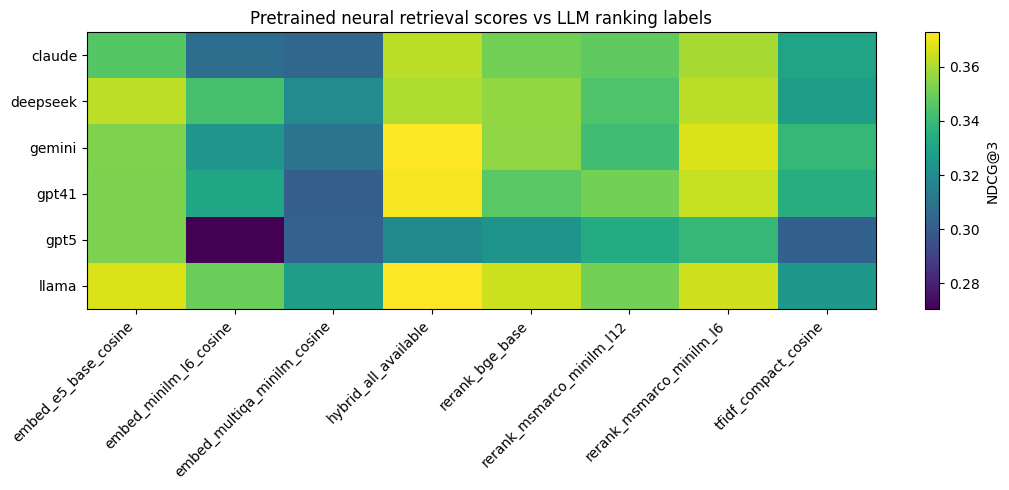

score_model,embed_e5_base_cosine,embed_minilm_l6_cosine,embed_multiqa_minilm_cosine,hybrid_all_available,rerank_bge_base,rerank_msmarco_minilm_l12,rerank_msmarco_minilm_l6,tfidf_compact_cosine
label_model,,,,,,,,
claude,0.322240,0.304724,0.305214,0.340744,0.321322,0.312371,0.316570,0.308551
deepseek,0.326017,0.310108,0.307993,0.350718,0.319720,0.309984,0.314610,0.305129
gemini,0.323230,0.301959,0.299393,0.342593,0.320957,0.310850,0.314057,0.313658
gpt41,0.320091,0.305116,0.299921,0.342350,0.319961,0.313899,0.316061,0.307213
gpt5,0.319822,0.295875,0.301795,0.323198,0.312599,0.309869,0.310342,0.299724
llama,0.333855,0.317347,0.316818,0.353623,0.321541,0.316994,0.320529,0.311084


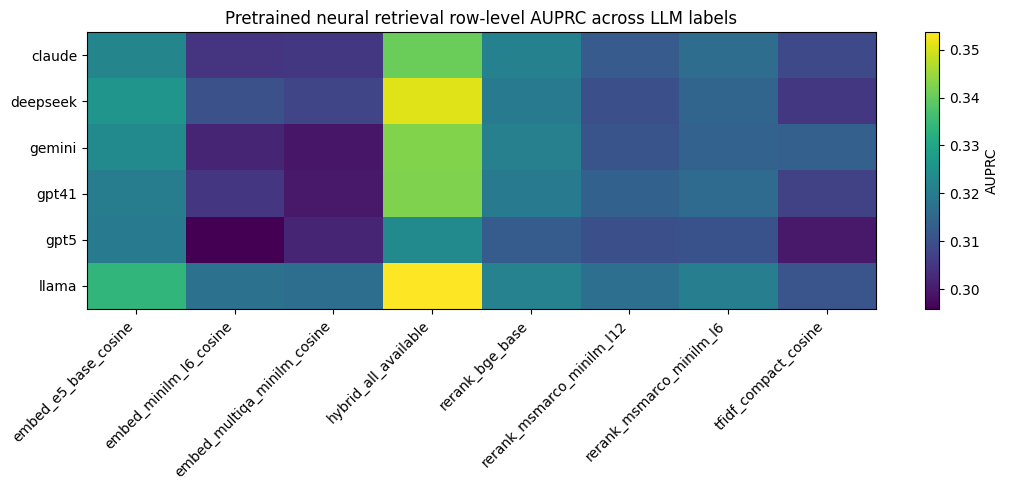

In [15]:
# NDCG@3 pivot
pivot_ndcg = query_metrics_all.pivot_table(
    index="label_model",
    columns="score_model",
    values="ndcg@3",
    aggfunc="mean"
)
pivot_ndcg.to_csv(DATA_DIR / "egeo_pretrained_neural_ndcg3_pivot_all_label_models.csv")
display(pivot_ndcg)

plt.figure(figsize=(11, 5))
plt.imshow(pivot_ndcg, aspect="auto")
plt.colorbar(label="NDCG@3")
plt.xticks(range(len(pivot_ndcg.columns)), pivot_ndcg.columns, rotation=45, ha="right")
plt.yticks(range(len(pivot_ndcg.index)), pivot_ndcg.index)
plt.title("Pretrained neural retrieval scores vs LLM ranking labels")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig03_pretrained_neural_ndcg3_heatmap_all_labels.png", dpi=300)
plt.show()

# AUPRC pivot
pivot_auprc = row_metrics_all.pivot_table(
    index="label_model",
    columns="score_model",
    values="AUPRC",
    aggfunc="mean"
)
pivot_auprc.to_csv(DATA_DIR / "egeo_pretrained_neural_auprc_pivot_all_label_models.csv")
display(pivot_auprc)

plt.figure(figsize=(11, 5))
plt.imshow(pivot_auprc, aspect="auto")
plt.colorbar(label="AUPRC")
plt.xticks(range(len(pivot_auprc.columns)), pivot_auprc.columns, rotation=45, ha="right")
plt.yticks(range(len(pivot_auprc.index)), pivot_auprc.index)
plt.title("Pretrained neural retrieval row-level AUPRC across LLM labels")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig03_pretrained_neural_auprc_heatmap_all_labels.png", dpi=300)
plt.show()


## 16. Best pretrained score per LLM label model

This table is useful for a short result summary.


Best by NDCG@3:


,precision@3,recall@3,ndcg@3,spearman_score_vs_negative_rank,label_model,score_model,score_col,n_rows,n_queries
7,0.352041,0.352041,0.362231,0.128633,claude,hybrid_all_available,score_hybrid_all_available,3920,392
11,0.355613,0.359469,0.362527,0.121018,deepseek,embed_e5_base_cosine,score_embed_e5_base_cosine,3878,389
23,0.363946,0.363946,0.372364,0.141899,gemini,hybrid_all_available,score_hybrid_all_available,3920,392
31,0.363095,0.363095,0.371167,0.146104,gpt41,hybrid_all_available,score_hybrid_all_available,3920,392
35,0.343537,0.343537,0.352369,0.084539,gpt5,embed_e5_base_cosine,score_embed_e5_base_cosine,3920,392
47,0.363946,0.363946,0.372677,0.149149,llama,hybrid_all_available,score_hybrid_all_available,3913,392


Best by AUPRC:


,AUROC,AUPRC,Accuracy,F1,threshold,label_model,score_model,score_col,n_rows,n_queries
7,0.552078,0.340744,0.610204,0.350340,0.611248,claude,hybrid_all_available,score_hybrid_all_available,3920,392
15,0.564583,0.350718,0.614750,0.355479,0.611362,deepseek,hybrid_all_available,score_hybrid_all_available,3878,389
23,0.553391,0.342593,0.609694,0.349490,0.611248,gemini,hybrid_all_available,score_hybrid_all_available,3920,392
31,0.551624,0.342350,0.612245,0.353741,0.611248,gpt41,hybrid_all_available,score_hybrid_all_available,3920,392
39,0.527372,0.323198,0.594388,0.323980,0.611248,gpt5,hybrid_all_available,score_hybrid_all_available,3920,392
47,0.575990,0.353623,0.621774,0.370213,0.611267,llama,hybrid_all_available,score_hybrid_all_available,3913,392


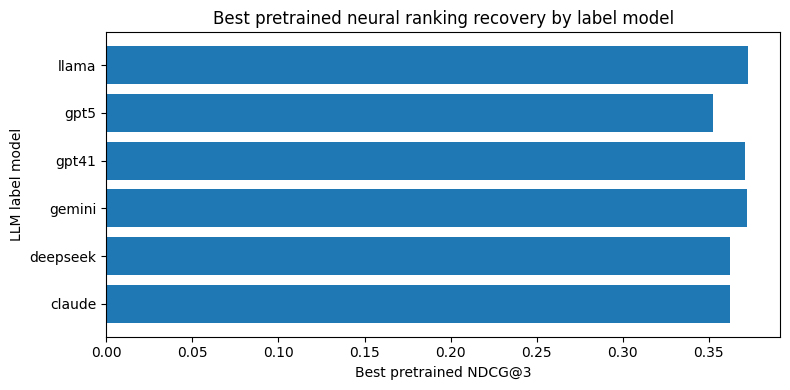

In [16]:
best_by_label_ndcg = (
    query_metrics_all
    .sort_values("ndcg@3", ascending=False)
    .groupby("label_model")
    .head(1)
    .sort_values("label_model")
)

best_by_label_auprc = (
    row_metrics_all
    .sort_values("AUPRC", ascending=False)
    .groupby("label_model")
    .head(1)
    .sort_values("label_model")
)

best_by_label_ndcg.to_csv(DATA_DIR / "egeo_pretrained_neural_best_ndcg3_by_label_model.csv", index=False)
best_by_label_auprc.to_csv(DATA_DIR / "egeo_pretrained_neural_best_auprc_by_label_model.csv", index=False)

print("Best by NDCG@3:")
display(best_by_label_ndcg)

print("Best by AUPRC:")
display(best_by_label_auprc)

plt.figure(figsize=(8, 4))
plt.barh(best_by_label_ndcg["label_model"], best_by_label_ndcg["ndcg@3"])
plt.xlabel("Best pretrained NDCG@3")
plt.ylabel("LLM label model")
plt.title("Best pretrained neural ranking recovery by label model")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig03_best_pretrained_ndcg3_by_label_model.png", dpi=300)
plt.show()


## 17. Compare pretrained neural baselines with notebook 01 trained ML

Notebook 01 already ran trained ML robustness across all labels.

This section combines:

- trained ML baselines from `egeo_cross_model_robustness_metrics.csv`
- pretrained neural retrieval/reranking baselines from this notebook


In [17]:
if prior_cross_model_metrics is not None:
    trained = prior_cross_model_metrics.copy()
    trained["source"] = "trained_ml"

    # Standardize naming.
    if "baseline_model" in trained.columns:
        trained["method"] = trained["baseline_model"]
    else:
        trained["method"] = "trained_ml"

    neural_q = query_metrics_all.copy()
    neural_q["source"] = "pretrained_neural"
    neural_q["method"] = neural_q["score_model"]

    # Query-level combined comparison.
    trained_q_cols = ["label_model", "method", "source", "precision@3", "recall@3", "ndcg@3"]
    trained_q_cols = [c for c in trained_q_cols if c in trained.columns]
    neural_q_cols = ["label_model", "method", "source", "precision@3", "recall@3", "ndcg@3"]
    neural_q_cols = [c for c in neural_q_cols if c in neural_q.columns]

    combined_q = pd.concat([
        trained[trained_q_cols],
        neural_q[neural_q_cols],
    ], ignore_index=True)

    combined_q.to_csv(DATA_DIR / "egeo_combined_query_metrics_trained_ml_and_pretrained_neural_all_labels.csv", index=False)
    display(combined_q.sort_values(["label_model", "ndcg@3"], ascending=[True, False]).head(50))

    # Best per source and label.
    best_combined_q = (
        combined_q
        .sort_values("ndcg@3", ascending=False)
        .groupby(["label_model", "source"])
        .head(1)
        .sort_values(["label_model", "source"])
    )
    best_combined_q.to_csv(DATA_DIR / "egeo_best_query_metrics_by_source_all_labels.csv", index=False)
    display(best_combined_q)

    # Figure: best NDCG@3 trained ML vs pretrained neural.
    pivot_best = best_combined_q.pivot_table(
        index="label_model",
        columns="source",
        values="ndcg@3",
        aggfunc="max"
    )

    ax = pivot_best.plot(kind="bar", figsize=(9, 5))
    ax.set_ylabel("Best NDCG@3")
    ax.set_xlabel("LLM label model")
    ax.set_title("Trained ML vs pretrained neural retrieval baselines")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "fig03_trained_ml_vs_pretrained_neural_ndcg3_all_labels.png", dpi=300)
    plt.show()

    # Row-level combined comparison if available.
    neural_r = row_metrics_all.copy()
    neural_r["source"] = "pretrained_neural"
    neural_r["method"] = neural_r["score_model"]

    if "AUPRC" in trained.columns:
        trained_r_cols = ["label_model", "method", "source", "AUROC", "AUPRC", "Accuracy", "F1"]
        trained_r_cols = [c for c in trained_r_cols if c in trained.columns]
        neural_r_cols = ["label_model", "method", "source", "AUROC", "AUPRC", "Accuracy", "F1"]
        neural_r_cols = [c for c in neural_r_cols if c in neural_r.columns]

        combined_r = pd.concat([
            trained[trained_r_cols],
            neural_r[neural_r_cols],
        ], ignore_index=True)
        combined_r.to_csv(DATA_DIR / "egeo_combined_row_metrics_trained_ml_and_pretrained_neural_all_labels.csv", index=False)
        display(combined_r.sort_values(["label_model", "AUPRC"], ascending=[True, False]).head(50))

        best_combined_r = (
            combined_r
            .sort_values("AUPRC", ascending=False)
            .groupby(["label_model", "source"])
            .head(1)
            .sort_values(["label_model", "source"])
        )
        best_combined_r.to_csv(DATA_DIR / "egeo_best_row_metrics_by_source_all_labels.csv", index=False)

        pivot_best_r = best_combined_r.pivot_table(
            index="label_model",
            columns="source",
            values="AUPRC",
            aggfunc="max"
        )

        ax = pivot_best_r.plot(kind="bar", figsize=(9, 5))
        ax.set_ylabel("Best AUPRC")
        ax.set_xlabel("LLM label model")
        ax.set_title("Row-level trained ML vs pretrained neural baselines")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "fig03_trained_ml_vs_pretrained_neural_auprc_all_labels.png", dpi=300)
        plt.show()
else:
    print("Notebook 01 cross-model trained ML metrics not found. Skipping trained ML comparison.")


Notebook 01 cross-model trained ML metrics not found. Skipping trained ML comparison.


## 18. Per-label model ranking examples

This saves high-agreement and low-agreement examples for each LLM label model.

Use these to inspect where pretrained neural relevance agrees or disagrees with a model's ranking trace.


In [18]:
# Choose a preferred score column for qualitative examples.
preferred_order = [
    "score_hybrid_all_available",
    "score_rerank_bge_base",
    "score_rerank_msmarco_minilm_l12",
    "score_rerank_msmarco_minilm_l6",
    "score_embed_e5_base_cosine",
    "score_embed_multiqa_minilm_cosine",
    "score_embed_minilm_l6_cosine",
    "score_tfidf_compact_cosine",
]

preferred_score_col = None
for col in preferred_order:
    if col in eval_with_scores.columns:
        preferred_score_col = col
        break

# If eval_with_scores was created before hybrid, merge updated scores again.
if preferred_score_col not in eval_with_scores.columns and preferred_score_col in scores_df.columns:
    eval_with_scores = eval_long.merge(
        scores_df[key_cols + score_cols_for_eval + ["score_hybrid_all_available"]],
        on=key_cols,
        how="inner"
    )

print("Preferred score for examples:", preferred_score_col)

if preferred_score_col is not None:
    example_records_high = []
    example_records_low = []

    for label_model in sorted(eval_with_scores["model"].unique()):
        df_l = eval_with_scores[eval_with_scores["model"] == label_model].copy()
        df_l = df_l.dropna(subset=[preferred_score_col])
        df_l["pred_score"] = df_l[preferred_score_col]

        q_metrics = query_level_metrics(df_l, score_col="pred_score", label_col="top3", k=3).reset_index()

        high_qids = q_metrics.sort_values("ndcg@3", ascending=False).head(5)["query_id"].astype(str).tolist()
        low_qids = q_metrics.sort_values("ndcg@3", ascending=True).head(5)["query_id"].astype(str).tolist()

        def collect_examples(qids, target_records, agreement_label):
            for qid in qids:
                g = df_l[df_l["query_id"].astype(str) == str(qid)].copy()
                if len(g) == 0:
                    continue
                g = g.sort_values("pred_score", ascending=False)
                query_text = g["query"].iloc[0] if "query" in g.columns else ""

                for _, row in g.iterrows():
                    target_records.append({
                        "agreement_type": agreement_label,
                        "label_model": label_model,
                        "query_id": qid,
                        "query": query_text,
                        "product_num": row.get("product_num"),
                        "title": row.get("title"),
                        "llm_rank": row.get("rank"),
                        "llm_top3": row.get("top3"),
                        "pretrained_score": row.get("pred_score"),
                        "score_column": preferred_score_col,
                    })

        collect_examples(high_qids, example_records_high, "high_agreement")
        collect_examples(low_qids, example_records_low, "low_agreement")

    high_examples = pd.DataFrame(example_records_high)
    low_examples = pd.DataFrame(example_records_low)

    high_examples.to_csv(DATA_DIR / "egeo_pretrained_neural_examples_high_agreement_all_labels.csv", index=False)
    low_examples.to_csv(DATA_DIR / "egeo_pretrained_neural_examples_low_agreement_all_labels.csv", index=False)

    print("High-agreement examples:")
    display(high_examples.head(30))

    print("Low-agreement examples:")
    display(low_examples.head(30))
else:
    print("No preferred score column available for examples.")


Preferred score for examples: score_hybrid_all_available
High-agreement examples:


,agreement_type,label_model,query_id,query,product_num,title,llm_rank,llm_top3,pretrained_score,score_column
0,high_agreement,claude,9323,Request for a beard trimmer: considering brand...,3,Andis 32400 Slimline Pro Cord/Cordless Beard T...,1,1,0.802885,score_hybrid_all_available
1,high_agreement,claude,9323,Request for a beard trimmer: considering brand...,6,Andis 23475 Professional PivotPro Beard & Hair...,2,1,0.764952,score_hybrid_all_available
2,high_agreement,claude,9323,Request for a beard trimmer: considering brand...,2,Wahl Lifeproof Rechargeable Trimmer No.09953-1...,3,1,0.756950,score_hybrid_all_available
3,high_agreement,claude,9323,Request for a beard trimmer: considering brand...,10,WAHL All in One LifeProof Cordless Rechargeabl...,4,0,0.652643,score_hybrid_all_available
4,high_agreement,claude,9323,Request for a beard trimmer: considering brand...,1,WAHL 9867-200 Lithium-ion Adjustable Beard and...,7,0,0.595833,score_hybrid_all_available
5,high_agreement,claude,9323,Request for a beard trimmer: considering brand...,9,Wahl 9876-506 Groomsman Revolution Rechargeabl...,8,0,0.587465,score_hybrid_all_available
6,high_agreement,claude,9323,Request for a beard trimmer: considering brand...,5,Wahl 9916-4101 Groomsman Beard and Stubble Rec...,9,0,0.512066,score_hybrid_all_available
7,high_agreement,claude,9323,Request for a beard trimmer: considering brand...,8,Wahl Professional - Sterling Bullet Clipper/Tr...,6,0,0.511243,score_hybrid_all_available
8,high_agreement,claude,9323,Request for a beard trimmer: considering brand...,7,Andis Pro All-in-One Lightweight Cord/Cordless...,5,0,0.437536,score_hybrid_all_available
9,high_agreement,claude,9323,Request for a beard trimmer: considering brand...,4,"Philips Norelco QT4010 Beard, Stubble and Mous...",10,0,0.195134,score_hybrid_all_available


Low-agreement examples:


,agreement_type,label_model,query_id,query,product_num,title,llm_rank,llm_top3,pretrained_score,score_column
0,low_agreement,claude,1015,I'm looking for a digital voice recorder on be...,3,Digital Voice Recorder 8G Voice Activated Reco...,4,0,0.924565,score_hybrid_all_available
1,low_agreement,claude,1015,I'm looking for a digital voice recorder on be...,7,"Digital Voice Recorder, CICIR 16GB Activated S...",8,0,0.750025,score_hybrid_all_available
2,low_agreement,claude,1015,I'm looking for a digital voice recorder on be...,8,"Sangean America, Inc - Sangean Dar-101 Digital...",9,0,0.616789,score_hybrid_all_available
3,low_agreement,claude,1015,I'm looking for a digital voice recorder on be...,5,"Digital Voice Recorder for Lecture, 200Hour Ba...",5,0,0.614196,score_hybrid_all_available
4,low_agreement,claude,1015,I'm looking for a digital voice recorder on be...,2,"64GB Digital Voice Recorder,Fillman Voice Acti...",7,0,0.583716,score_hybrid_all_available
5,low_agreement,claude,1015,I'm looking for a digital voice recorder on be...,9,Digital Voice Recorder for Lectures by Aiworth...,6,0,0.555830,score_hybrid_all_available
6,low_agreement,claude,1015,I'm looking for a digital voice recorder on be...,1,"GeeOODs 32 GB Voice Recorder, Voice Activated ...",3,1,0.351981,score_hybrid_all_available
7,low_agreement,claude,1015,I'm looking for a digital voice recorder on be...,4,Philips DVT1100 4GB Digital Voice Recorder wit...,1,1,0.278486,score_hybrid_all_available
8,low_agreement,claude,1015,I'm looking for a digital voice recorder on be...,10,Memorex MB005 Digital Voice Recorders,10,0,0.163058,score_hybrid_all_available
9,low_agreement,claude,1015,I'm looking for a digital voice recorder on be...,6,OM Digital Solutions Voice Recorder DM-720 wit...,2,1,0.116373,score_hybrid_all_available


## 19. Scatter plots: pretrained score vs rank by label model

These are diagnostic plots.

A useful pattern is:

```text
higher pretrained score → lower/better LLM rank
```


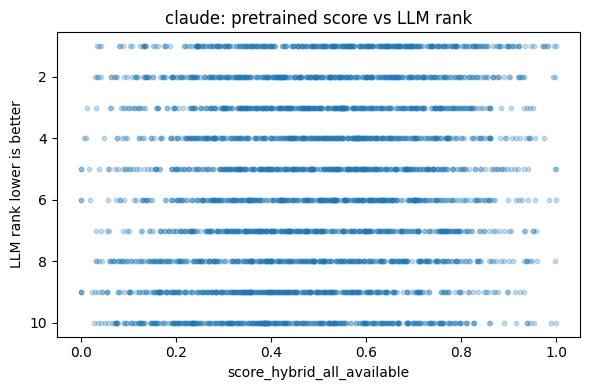

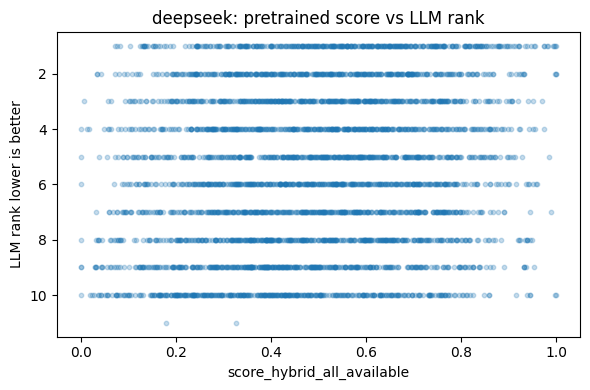

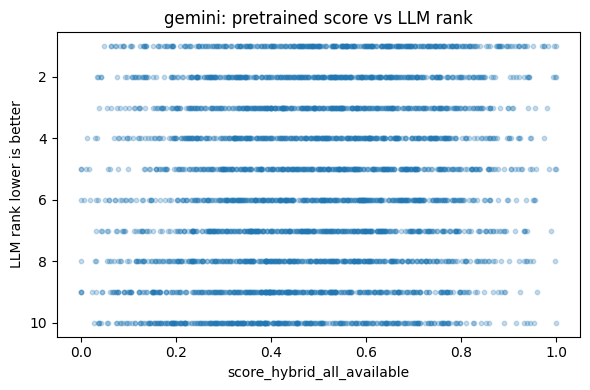

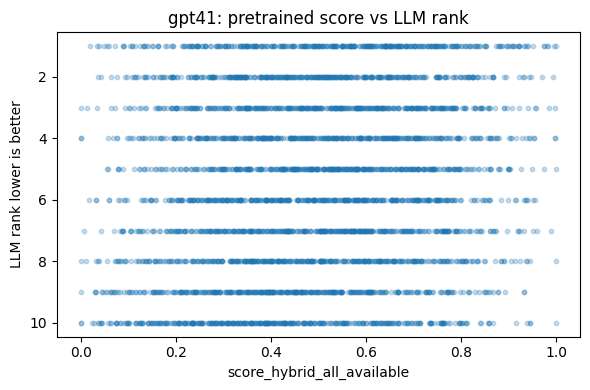

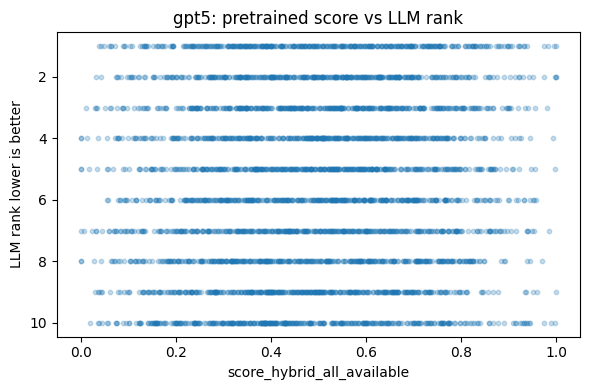

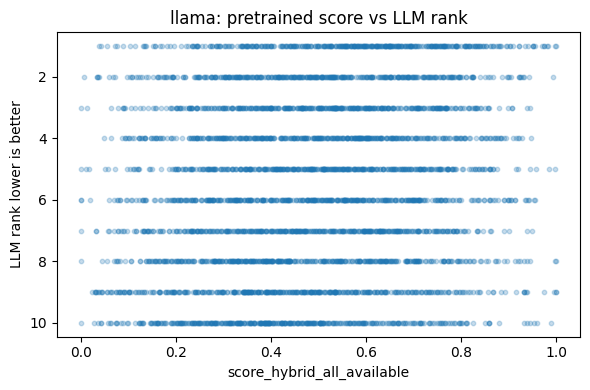

In [19]:
if preferred_score_col is not None:
    for label_model in sorted(eval_with_scores["model"].unique()):
        df_l = eval_with_scores[eval_with_scores["model"] == label_model].copy()
        if preferred_score_col not in df_l.columns:
            continue
        df_l = df_l.dropna(subset=[preferred_score_col, "rank"])

        plt.figure(figsize=(6, 4))
        plt.scatter(df_l[preferred_score_col], df_l["rank"], alpha=0.25, s=10)
        plt.gca().invert_yaxis()
        plt.xlabel(preferred_score_col)
        plt.ylabel("LLM rank lower is better")
        plt.title(f"{label_model}: pretrained score vs LLM rank")
        plt.tight_layout()
        safe_label = str(label_model).replace("/", "_")
        plt.savefig(FIGURES_DIR / f"fig03_score_vs_rank_{safe_label}.png", dpi=300)
        plt.show()
else:
    print("No preferred score column available for scatter plots.")


## 20. Final summary table

This creates a compact summary for slides or professor updates.


In [20]:
summary_rows = []

summary_rows.append({
    "item": "Task",
    "value": "Recover all available LLM top-3 product ranking traces using pretrained neural retrieval/reranking models"
})
summary_rows.append({
    "item": "Evaluation query-product rows across labels",
    "value": len(eval_with_scores)
})
summary_rows.append({
    "item": "Unique query-product rows scored",
    "value": len(scores_df)
})
summary_rows.append({
    "item": "LLM label models evaluated",
    "value": ", ".join(sorted(eval_with_scores["model"].unique()))
})
summary_rows.append({
    "item": "Pretrained score columns evaluated",
    "value": ", ".join(score_cols_for_eval)
})

if len(best_by_label_ndcg) > 0:
    avg_best_ndcg = best_by_label_ndcg["ndcg@3"].mean()
    summary_rows.append({
        "item": "Mean best pretrained NDCG@3 across label models",
        "value": float(avg_best_ndcg)
    })

if len(best_by_label_auprc) > 0:
    avg_best_auprc = best_by_label_auprc["AUPRC"].mean()
    summary_rows.append({
        "item": "Mean best pretrained AUPRC across label models",
        "value": float(avg_best_auprc)
    })

summary = pd.DataFrame(summary_rows)
summary.to_csv(DATA_DIR / "egeo_pretrained_neural_all_labels_summary_table.csv", index=False)
display(summary)


,item,value
0,Task,Recover all available LLM top-3 product rankin...
1,Evaluation query-product rows across labels,23471
2,Unique query-product rows scored,3920
3,LLM label models evaluated,"claude, deepseek, gemini, gpt41, gpt5, llama"
4,Pretrained score columns evaluated,"score_tfidf_compact_cosine, score_embed_minilm..."
5,Mean best pretrained NDCG@3 across label models,0.365556
6,Mean best pretrained AUPRC across label models,0.342204


## 21. Suggested interpretation paragraph

Use this after checking the actual numbers.

> I added an all-model pretrained neural retrieval analysis on top of the existing E-GEO pipeline. Instead of fine-tuning a model or calling an LLM API, this analysis uses off-the-shelf embedding and cross-encoder reranker models to score each query-product pair. The same pretrained scores are then evaluated against each available LLM ranking trace, including GPT-5, GPT-4.1, Gemini, Claude, DeepSeek, and Llama. This tests whether generic neural retrieval relevance can recover model-specific AI shopping visibility. The analysis also compares pretrained neural retrieval baselines with the trained ML baselines from the first notebook, using query-level metrics such as Precision@3, Recall@3, and NDCG@3, as well as row-level AUROC and AUPRC.

Short Slack version:

> I also added an all-model pretrained neural retrieval baseline. It does not fine-tune or call an LLM. It scores each query-product pair using pretrained sentence-embedding and cross-encoder reranker models, then checks how well those scores recover the existing GPT-5, GPT-4.1, Gemini, Claude, DeepSeek, and Llama top-3 ranking traces.
